# PHYS3116 Group Assessment

In [1]:
# Import the libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import ascii
from astropy.coordinates import SkyCoord, Angle
from astropy.table import Table, QTable
import plotly.express as px
import scipy.stats as stats
from scipy.optimize import curve_fit

In [2]:
# LaTeX initialisation
# Many LaTeX parameters set to NULL otherwise plots take 84392409432 years to initialise and run

plt.savefig("amr_plot.png", dpi=300, bbox_inches="tight")
plt.rcParams['figure.dpi'] = 150
plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

<Figure size 640x480 with 0 Axes>

In [3]:
# Read in data files
harris_p1 = pd.read_csv('HarrisPartI.csv')
harris_p2 = pd.read_csv('HarrisPartII.csv')
harris_p3 = pd.read_csv('HarrisPartIII.csv')
krause = pd.read_csv('Krause21.csv')
vandenberg = pd.read_csv('vandenBerg_table2.csv') 
progenitor = pd.read_csv('Progenitor.csv')

---
## Data Info  ⋆｡ﾟ⋆.݁⟡ ݁ﾟ⊹₊݁.ﾟ☾ ﾟ｡⋆.𖥔 ݁˖°.
---
**Harris Part I - Cluster identifications and positions**
- ['RA'], ['DEC'] Right ascention and Declination (epoch J2000)
- ['L'], ['B'] Galactic longitude and latitude (degrees)
- ['R_Sun'] Distance from Sun (kiloparsecs)
- ['R_gc'] Distance from Galactic center (kpc), assuming R_0=8.0 kpc
- ['X'], ['Y'], ['Z'] Galactic distance components X,Y,Z in kiloparsecs, in a Sun-centered coordinate system; X points toward Galactic center, Y in direction of Galactic rotation, Z toward North Galactic Pole
---
**Harris Part II - Metallicities, Integrated magnitudes, colors** 
- ['Fe/H'] Metallicity [Fe/H]
- ['wt'] Weight of mean metallicity; essentially the number of independent [Fe/H] measurements averaged together.
- ['E(B-V)'] Foreground reddening
- ['V_HB'] V magnitude level of the horizontal branch (or RR Lyraes)
- ['(m-M)V'] Apparent visual distance modulus
- ['V_t'] Integrated V magnitude of the cluster
- ['M_V,t'] Absolute visual magnitude (cluster luminosity),  M_V,t = V_t - (m-M)V
- ['U-B'], ['B-V'], ['V-R'], ['V-I'] Integrated color indices (uncorrected for reddening)
- ['spt] Spectral type of the integrated cluster light
- ['ellip'] Projected ellipticity of isophotes, e = 1-(b/a)
---
**Harris Part III - Radial velocities, velocity dispersions, structural parameters** 
- ['v_r'] Heliocentric radial velocity (km/s)
- ['v_r_e'] Observational (internal) uncertainty in radial velocity
- ['v_LSR'] Radial velocity relative to Solar neighborhood LSR
- ['sig_v'] Central velocity dispersion sig_v (km/s)
- ['sig_v_e'] Observational (internal) uncertainty in velocity dispersion
- ['c'] King-model central concentration, c = log(r_t/r_c); a 'c' denotes a core-collapsed cluster
- ['r_c'] Core radius in arcmin
- ['r_h'] Half-light radius in arcmin
- ['mu_V'] Central surface brightness, V magnitudes per square arcsecond
- ['rho_0'] Central luminosity density, log_10(Solar luminosities per cubic parsec)
- ['lg_tc'] Core relaxation time t(r_c), in log_10(years)
- ['lg_th'] Median relaxation time t(r_h), in log_10(years)
---
**Krause**
- ['Mstar'] Stellar mass (Mstar) of the object
- ['rh'] Half-light radius (rh) of the object
- ['C5'] Compactness parameter (C5) of the object
- ['Age'] Age of the object (Gyr)
- ['FeH'] Metallicity [Fe/H]
---
**VandenBerg**
- ['FeH'] Metallicity [Fe/H]
- ['Age'] Age of the object (Gyr)
- ['Age_err'] Age uncertainty
- ['Method']
- ['Figs']
- ['Range']
- ['HBtype']
- ['R_G'] Distance from Galactic center (kpc)
- ['M_V'] Absolute visual magnitude
- ['v_e0'] Central escape velocity
- ['log_sigma_0'] Central logarithmic velocity dispersion
---

**What we expect to see**
* Accreted versus In Situ Milky Way Globular Clusters, Forbes (2024)
    -  The age-metallicity relation for the Milky Way’s GCs reveals two distinct tracks – one with near constant old age of ∼12.8 Gyr and the other branches to younger ages.
    - Retrograde orbit GCs (a key signature of accretion) are commonly found in the young track.
    - about 1/4 of the entire system were accreted to build the Milky Way GC system we seen today.
    - These accreted stars tended to be acquired early on, and are mostly in place 9 Gyr ago. The in situ stars, on the other hand, generally formed at very early epochs and are more than 11.5 Gyr old.
* In-situ versus accreted Milky Way globular clusters: a new classification method and implications for cluster formation, Belokurov (2023)
    - New scheme using total energy E and z-component of the orbital angular momentum and is calibrated using the [Al/Fe] abundance ratio
    - The in-situ GCs are distributed within the central 10 kpc of the Galaxy in a flattened configuration aligned with the Milky Way (MW) disc, while the accreted GCs have a wide distribution of distances and a spatial distribution close to spherical
    - The in-situ GCs in our classification show a clear disc spin-up signature – the increase of median Vφ at metallicities −1.3 < [Fe/H] < −1 similar to the spin-up in the in-situ field stars. This signature signals the MW’s disc formation, which occurred ≈11.7−12.7 Gyr ago (or at z ≈ 3.1−5.3) according to in-situ GC ages. In-situ GCs with metallicities of [Fe/H]  −1.3 were thus born in the MW disc, while lower metallicity in-situ GCs were born during early, turbulent, pre-disc stages of the evolution of the Galaxy and are part of its Aurora stellar component.
* The dynamical evolution of accreted star clusters in the Milky Way,  Miholics (2015)
    - Since the Milky Way was built up through mergers with dwarf galaxies, its globular cluster population is made up of clusters formed both during the initial collapse of the Galaxy and in dwarf galaxies that were later accreted
* Origin of the system of globular clusters in the Milky Way, Massari (2019)
    - Figure 1 shows the AMR for the clusters in our sample, colourcoded according to various dynamical properties, namely apo, circ, Zmax and ecc. It is immediately clear that the clusters located on the young and metal-rich branch of the AMR are dynamically different from those on the young and metal-poor branch. Young and metal-rich GCs typically do not reach high altitudes above the Galactic plane (Zmax), have smaller apocentres, and tend to have lower eccentricities. As already recognised in the literature (e.g. Leaman et al. 2013), these are the clusters formed in situ, either in the disc or in the bulge, in what we hereafter refer to as the Main Progenitor.


In [4]:
# Harris Part 1: make naming consistent
harris_p1.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p1['Object'] = harris_p1['Object'].astype(str) # make sure object column is string type
harris_p1['Object'] = harris_p1['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Harris Part 2: make naming consistent
harris_p2.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p2['Object'] = harris_p2['Object'].astype(str) # make sure object column is string type
harris_p2['Object'] = harris_p2['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Harris Part 3: make naming consistent
harris_p3.rename(columns={'ID': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
harris_p3['Object'] = harris_p3['Object'].astype(str) # make sure object column is string type
harris_p3['Object'] = harris_p3['Object'].str.replace(' ', '', regex=True) # remove spaces from object names

# Krause: naming already consistent

# VandenBerg: make naming consistent
vandenberg.rename(columns={'#NGC': 'Object'}, inplace=True) # rename column to 'Object' to match other dataframes
vandenberg['Object'] = vandenberg['Object'].astype(str) # make sure object column is string type
vandenberg['Object'] = 'NGC' + vandenberg['Object'] # add NGC to the start of each object
# inspect what the problematic rows look like
mask = vandenberg['Object'].str.upper() == 'NGCXXXX'
vandenberg.loc[mask, 'Object'] = vandenberg.loc[mask, 'Name'].astype(str)

In [5]:
# merge data frames
merged_all = pd.merge(harris_p1, harris_p3, on='Object')
merged_all = pd.merge(merged_all, vandenberg, on='Object')
merged_all = pd.merge(merged_all, krause, on='Object')

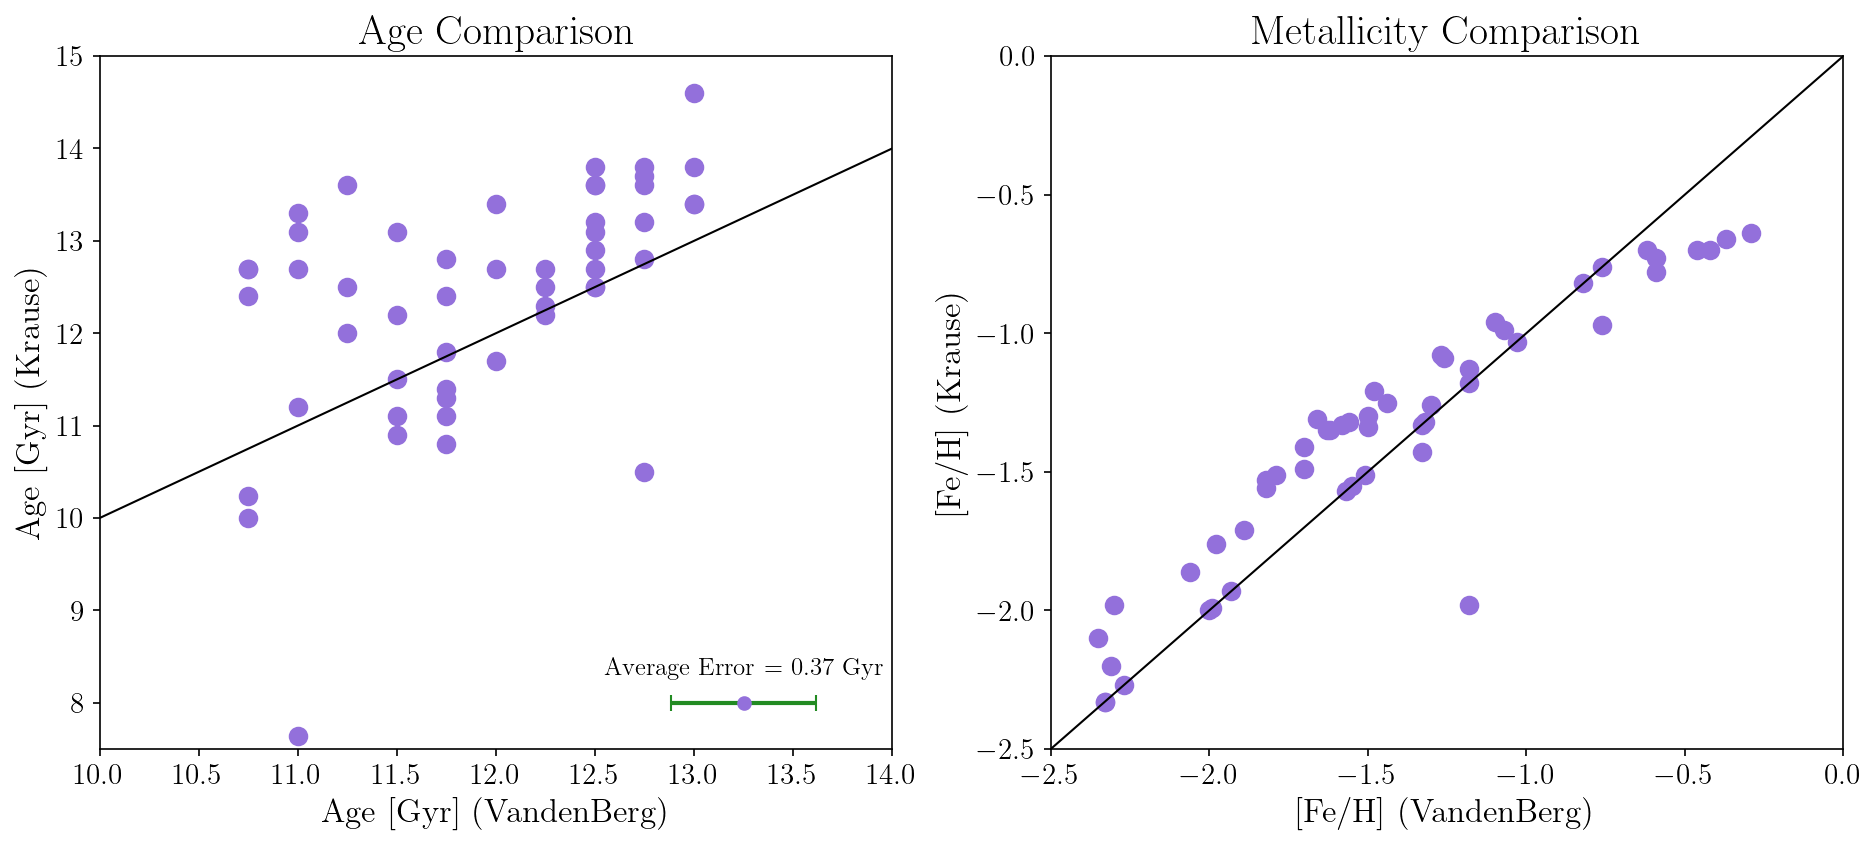

In [6]:
# Plotting comparisons between VandenBerg and Krause data
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # 1 row, 2 columns

# Age comparison
axes[0].scatter(merged_all['Age_x'], merged_all['Age_y'], color='mediumpurple', s=70)
axes[0].plot([10, 15], [10, 15], c='black', linestyle='-', lw=1, label='1:1 Line') # Add 1:1 line

# add a representative error bar in corner
errorbar = merged_all['Age_err'].mean()  # average error
axes[0].errorbar(13.25, 8, xerr=errorbar, marker='o', color='mediumpurple', ecolor='forestgreen', capsize=4, lw=2)
axes[0].text(13.25, 8.3, f'Average Error = {errorbar:.2f} Gyr', fontsize=12, ha='center') # error bar text

axes[0].set_xlabel('Age [Gyr] (VandenBerg)', fontsize=16)
axes[0].set_ylabel('Age [Gyr] (Krause)', fontsize=16)
axes[0].set_xlim(10, 14)
axes[0].set_ylim(7.5, 15)
axes[0].set_title('Age Comparison', fontsize=20)
axes[0].tick_params(axis='both', which='major', labelsize=14)

# [Fe/H] comparison
axes[1].scatter(merged_all['FeH_x'], merged_all['FeH_y'], color='mediumpurple', s=70)
axes[1].plot([-2.5, 0], [-2.5, 0], c='k', linestyle='-', lw=1, label='1:1 Line') # Add 1:1 line
axes[1].set_xlabel('[Fe/H] (VandenBerg)', fontsize=16)
axes[1].set_ylabel('[Fe/H] (Krause)', fontsize=16)
axes[1].set_xlim(-2.5, 0)
axes[1].set_ylim(-2.5, 0)
axes[1].set_title('Metallicity Comparison', fontsize=20)
axes[1].tick_params(axis='both', which='major', labelsize=14)

plt.show()


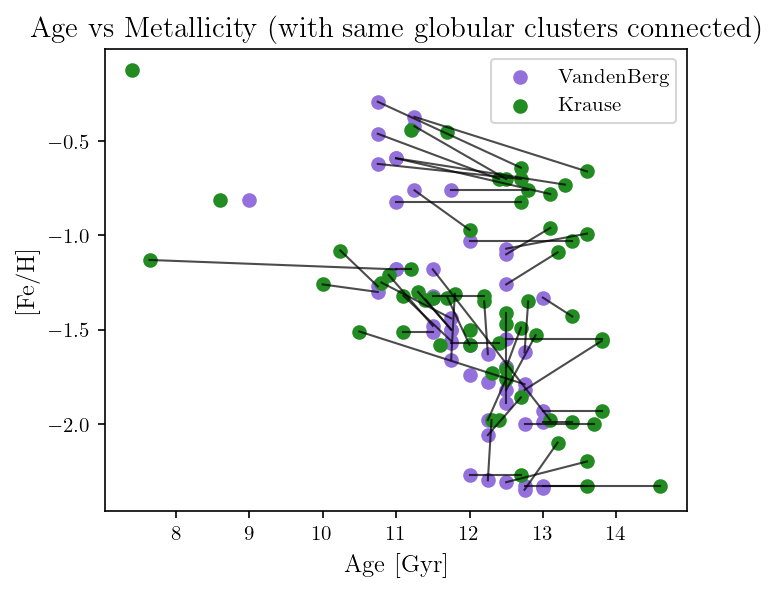

In [7]:
# Age-metallicity plot with data from VandenBerg and Krause with lines connecting matching objects
plt.figure(figsize=(5, 4))
plt.scatter(vandenberg['Age'], vandenberg['FeH'], marker='o', c='mediumpurple', label='VandenBerg')
plt.scatter(krause['Age'], krause['FeH'], marker='o', c='forestgreen', label='Krause')

# Connect matching objects
for object in set(vandenberg['Object']).intersection(krause['Object']): # find common objects
    v = vandenberg[vandenberg['Object'] == object].iloc[0] # get object row for vandenberg
    k = krause[krause['Object'] == object].iloc[0]  # get object row for krause
    plt.plot([v['Age'], k['Age']], [v['FeH'], k['FeH']],color='k', linestyle='-', linewidth=1, alpha=0.7) # plot line between same objects

# labels
plt.title('Age vs Metallicity (with same globular clusters connected)', fontsize=14)
plt.xlabel('Age [Gyr]', fontsize=12)
plt.ylabel('[Fe/H]', fontsize=12)
plt.legend()
plt.show()

In [8]:
# keep only the vandenberg (x) values for FeH, Age, and R_gc
merged_all['FeH'] = merged_all['FeH_x']
merged_all['Age'] = merged_all['Age_x']
merged_all['r_gc'] = merged_all['R_gc'] # The Galactocentric radius from Harris and VandenBerg have the same values

# drop the unusable columns
merged_all = merged_all.drop(columns=['FeH_x', 'FeH_y', 'Age_x', 'Age_y', 'R_gc', 'R_G'])

In [9]:
# Extracting key spatial coordinates
R = harris_p1["R_gc"]
X = harris_p1["X"]
Y = harris_p1["Y"]
Z = harris_p1["Z"]
names = harris_p1["Object"]

ages_v = vandenberg["Age"]
feh_v  = vandenberg["FeH"]

## Identifying Clusters with Dynamical Data

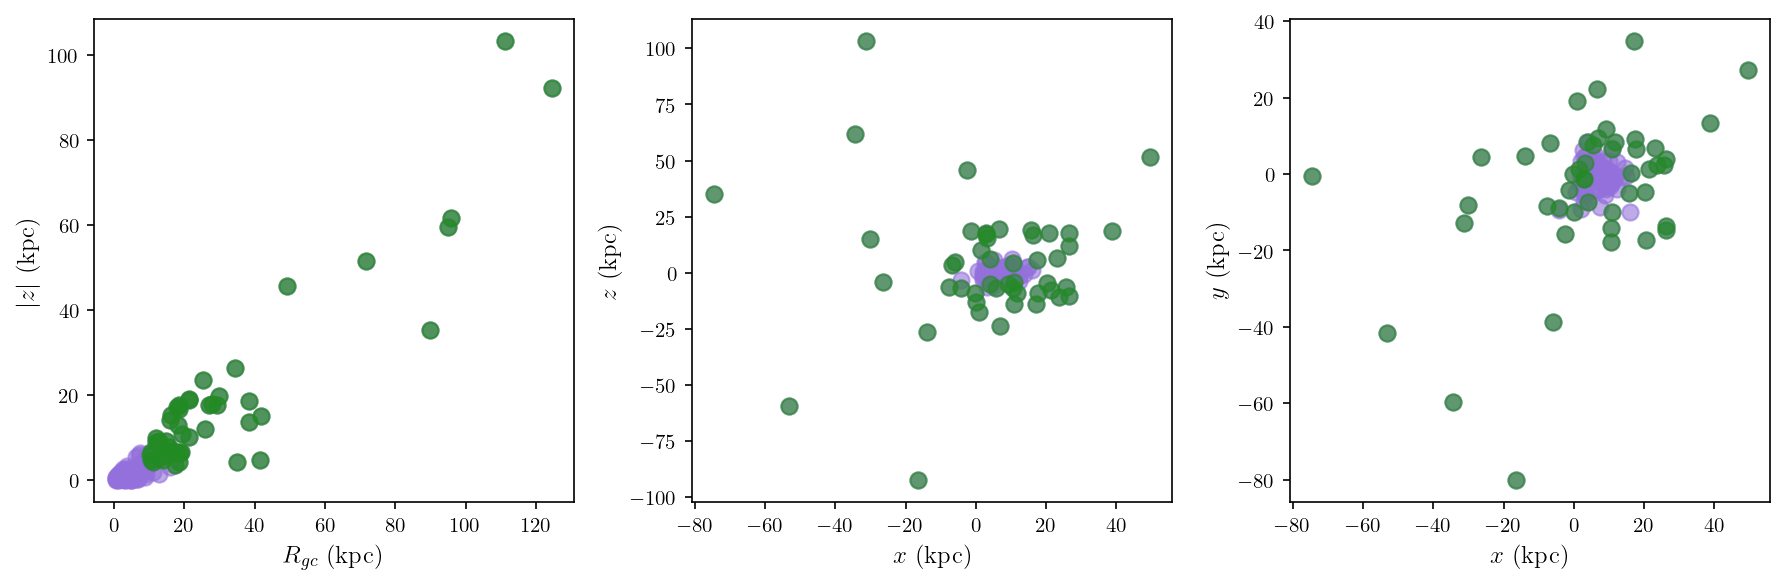

In [10]:
# Obtaining data-set and taking relevant columns


# Identification of accreted clusters
mask = (R > 10) & (abs(Z) > 3)
accreted = harris_p1[mask]
#print("Accreted clusters (R_gc > 10 and |Z| > 3):")
#print(accreted[["ID", "R_gc", "Z"]])

# Create subplots, same code as above
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# R vs |Z|
axes[0].scatter(R, abs(Z), c='mediumpurple', alpha=0.6, s=60)
axes[0].scatter(accreted["R_gc"], abs(accreted["Z"]), c='forestgreen', alpha=0.7, s=60)
axes[0].set_xlabel(r"$R_{gc}$ (kpc)", fontsize=12)
axes[0].set_ylabel(r"$|z|$ (kpc)", fontsize=12)

# X vs Z
axes[1].scatter(X, Z, c='mediumpurple', alpha=0.6, s=60)
axes[1].scatter(accreted["X"], accreted["Z"], c='forestgreen', alpha=0.6, s=60)
axes[1].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[1].set_ylabel(r"$z$ (kpc)", fontsize=12)

# X vs Y
axes[2].scatter(X, Y, c='mediumpurple', alpha=0.6, s=60)
axes[2].scatter(accreted["X"], accreted["Y"], c='forestgreen', alpha=0.6, s=60)
axes[2].set_xlabel(r"$x$ (kpc)", fontsize=12)
axes[2].set_ylabel(r"$y$ (kpc)", fontsize=12)

plt.tight_layout()
plt.show()

## Age-metallicity Relation

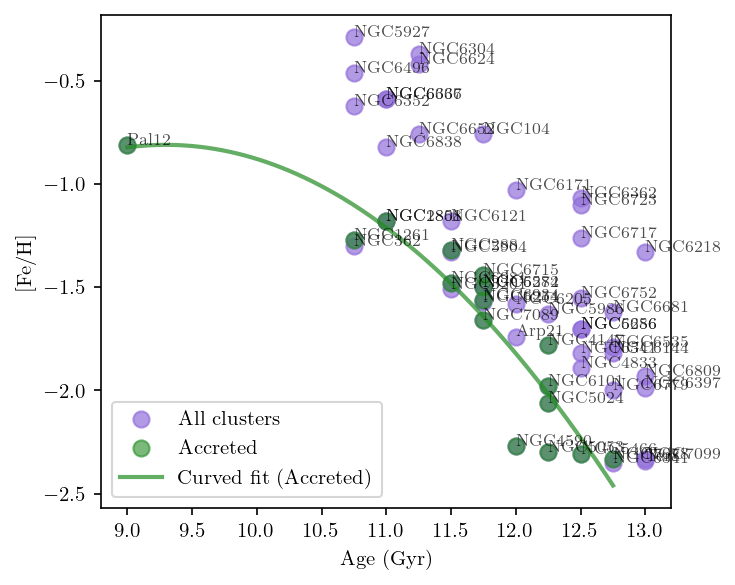

In [ ]:
# Identify accreted clusters
mask = (harris_p1["R_gc"] > 10) & (abs(harris_p1["Z"]) > 3)
accreted_names = harris_p1.loc[mask, "Object"]

# Find those names vandenBerg dataset
vberg_mask  = vandenberg["Object"].isin(accreted_names)

# Search through age-metallicity data for clusters that were identified as accreted above
feh_acc = feh_v[vberg_mask]
ages_acc = ages_v[vberg_mask]

# Defined polynomial fit
coeffs = np.polyfit(ages_acc, feh_acc, 2)
a, b, c = coeffs

# Curve fitting
x_fit = np.linspace(min(ages_acc), max(ages_acc), 200)  # Age range
y_fit = a * x_fit**2 + b * x_fit + c                   # [Fe/H] fit

# Plot
plt.figure(figsize=(5,4))

# All clusters (no longer including Krause21)
plt.scatter(ages_v, feh_v, c='mediumpurple', alpha=0.7, s=60, label="All clusters")

# Accreted clusters
plt.scatter(ages_acc, feh_acc, c='forestgreen', alpha=0.6, s=60, label="Accreted")

# # label points with object names
# for i, txt in enumerate(vandenberg['Object']):
#     plt.annotate(txt, (vandenberg['Age'][i], vandenberg['FeH'][i]), fontsize=8, alpha=0.7)

# Curved best-fit line
plt.plot(x_fit, y_fit, color='forestgreen', alpha=0.7, linewidth=2, label="Curved fit (Accreted)")

plt.xlabel("Age (Gyr)")
plt.ylabel("[Fe/H]")
plt.legend()
plt.tight_layout()
plt.show()

- Dwarf galaxies are the main sources of accreted globular clusters in the Milky Way.

- Their low metallicity arises from supernova-driven gas loss, as shallow gravitational potentials allow enriched material to escape easily.

- The curved age–metallicity relation (AMR) in Figure 1 reflects gradual chemical enrichment: later generations form from gas increasingly enriched in heavy elements.

- In-situ clusters formed within the Milky Way show systematically higher 
[Fe/H]
[Fe/H] at similar ages due to stronger gravitational retention of metals and more efficient star formation.

- Both accreted and in-situ populations follow the same physical trend of increasing 
[Fe/H] with time, but differ in enrichment rate and metallicity scale because of their distinct formation environments.

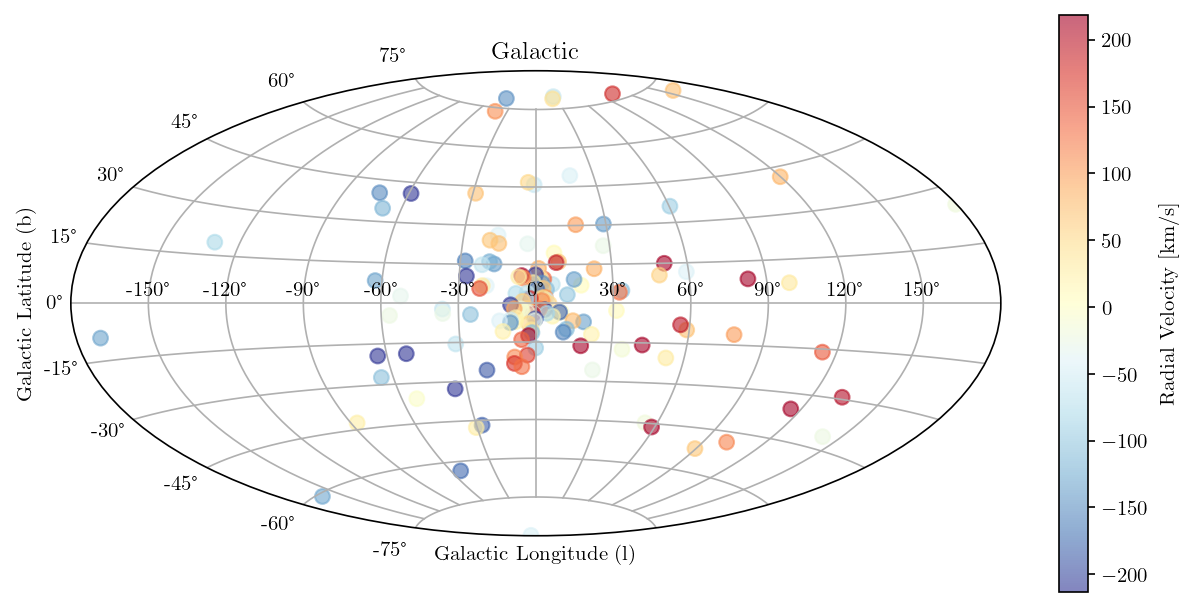

In [18]:
# plot sky distribution of GCs in Galactic coordinates

harris_p1['L'] = pd.to_numeric(harris_p1['L'], errors='coerce')
harris_p1['B'] = pd.to_numeric(harris_p1['B'], errors='coerce')
harris_p3['v_r'] = pd.to_numeric(harris_p3['v_r'], errors='coerce')

# Convert pandas into Angle objects
l = Angle(harris_p1['L'].to_numpy(), unit='deg')
b = Angle(harris_p1['B'].to_numpy(), unit='deg')
rv = harris_p3['v_r'].to_numpy()  # Radial Velocity

# Plot Galactic Coords
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='aitoff')
sc = ax.scatter(-l.wrap_at('180d').radian, b.radian, s=50, c=rv, cmap='RdYlBu_r', vmin=np.nanpercentile(rv, 5), vmax=np.nanpercentile(rv, 95), marker='o', alpha=0.6)
plt.colorbar(sc, ax=ax, label='Radial Velocity [km/s]')
ax.set_xlabel("Galactic Longitude (l)")
ax.set_ylabel("Galactic Latitude (b)")
ax.set_title("Galactic")

# # label points with object names
# for i, txt in enumerate(harris_p1['Object']):
#     plt.annotate(txt, xy=(-l.wrap_at('180d').radian[i], b.radian[i]), xytext=(3, 3), textcoords='offset points', fontsize=6, alpha=0.7,)

ax.grid()
plt.show()

# Figure displays GCs in Galactic coordinates with the centre of the Galaxy at the origin
# blue is blue shifted (moving towards us)
# red is red shifted (moving away from us)

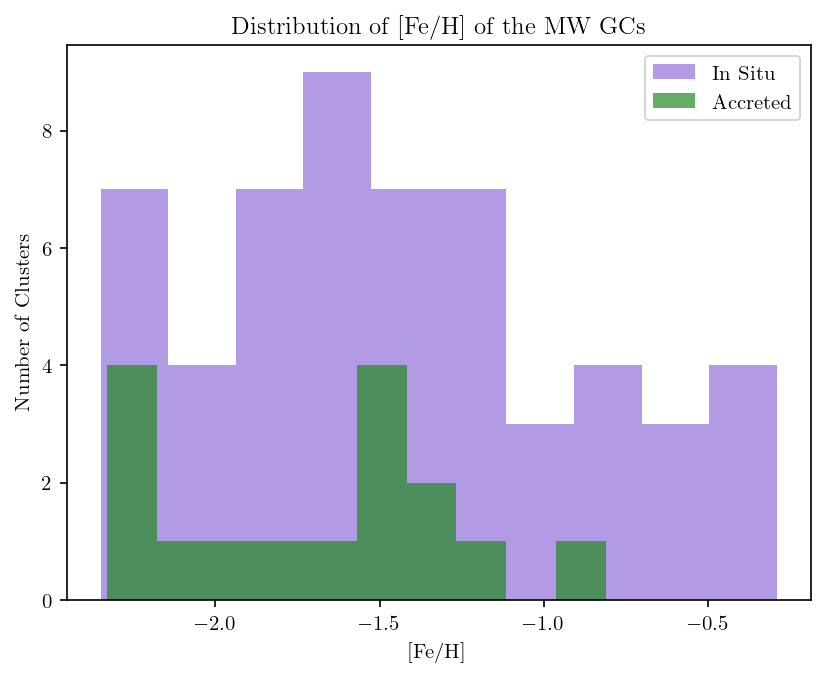

In [21]:
feh_acc = feh_v[vberg_mask]

# plot histogram
plt.hist(feh_v, bins=10, color='mediumpurple', alpha=0.7, label='In Situ')
plt.hist(feh_acc, bins=10, color='forestgreen', alpha=0.7, label='Accreted')

plt.xlabel('[Fe/H]')
plt.ylabel('Number of Clusters')
plt.legend()
plt.title('Distribution of [Fe/H] of the MW GCs')
plt.show()

# bimodality in the metallicity distribution should only be present in the in-situ GCs.
